## **Duffing oscillator**



## **I. Setup and Preprocessing**

In [2]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

[5.48357077 2.30867849]
Guess highest order polynomial: 3


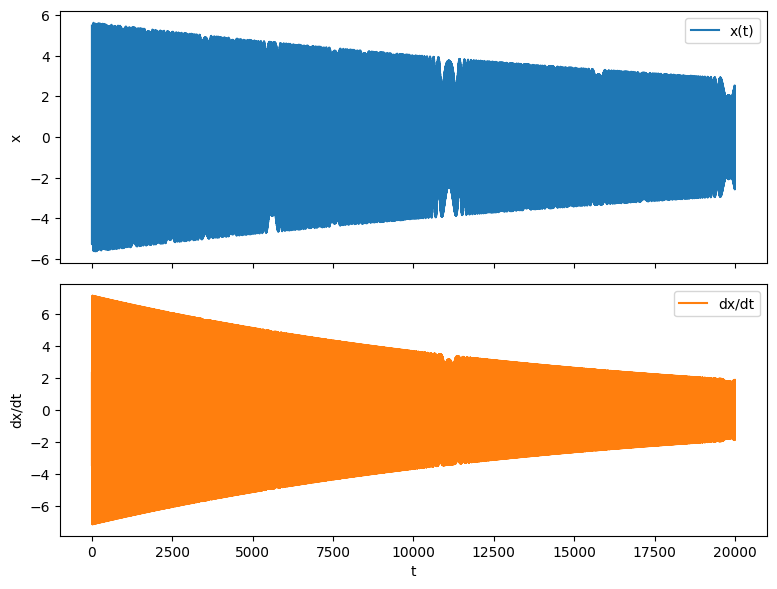

Training input shape: (10000, 2)
Training output shape: (10000, 2)


In [3]:
# Specify the model type
MY_MODEL = 'duffing'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
num_traj = 1
data_initial_conditions = []
for i in range(num_traj):
    x0 = np.random.normal(3, 5.0, size=2)  # [x, dx/dt]
    data_initial_conditions.append(x0)

print(data_initial_conditions[0])

data_T = 20000.0       # Length of the data (T)
data_dt = 2.0     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, random_state=SEED)
p=[0.0001,0.01, 0.1]
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(
    MY_MODEL, p, method='DOP853')


print("Guess highest order polynomial:", guess_highest_order_polynomial)

# Plot response for the first trajectory
import matplotlib.pyplot as plt

steps = t_arr.shape[0]
t_plot = t_arr.squeeze()
x_first = x_train[:steps, 0]
xdot_first = x_train[:steps, 1]

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t_plot, x_first,label='x(t)')
ax[0].set_ylabel('x')
ax[0].legend()
ax[1].plot(t_plot, xdot_first, label='dx/dt', color='tab:orange')
ax[1].set_ylabel('dx/dt')
ax[1].set_xlabel('t')
ax[1].legend()
plt.tight_layout()
plt.show()

# Shuffle data
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)


### **1.3 Hyperparameters**



In [4]:
# Set mini-batch size
MINI_BATCH_SIZE = 100
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

**SREINet Parameters**


In [5]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[2, 2, 2]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [6]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [7]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [8]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 trainer**


In [9]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**


#### **Pruning Profile**


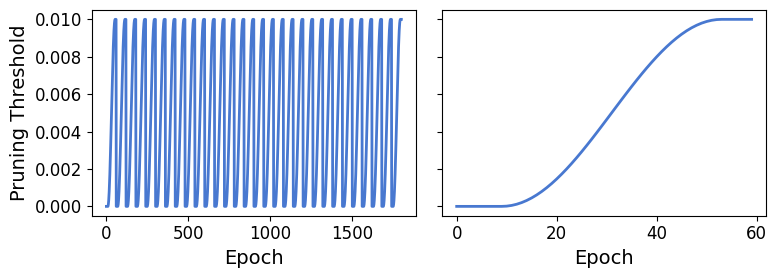

In [10]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.01 #.3-.35 
N_PERIODS = 30
PRUNING_EPOCHS_PER_PERIOD = 60
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)


In [11]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.0001

training_histories = []
weights_list = []
loss_list = []


In [12]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0,training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 2
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 2.882e+00,  Validation Loss: 5.485e-01,  Epoch Time: 0.29s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 1.217e-01,  Validation Loss: 7.330e-03,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 3.412e-03,  Validation Loss: 1.242e-03,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 8.388e-04,  Validation Loss: 4.425e-04,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 3.495e-04,  Validation Loss: 2.810e-04,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 1.818e-04,  Validation Loss: 1.445e-04,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.104e-04,  Validation Loss: 8.326e-05,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 5.974e-05,  Validation Loss: 6.132e-05,  Epoch

In [13]:
weights_list[1]

[[array([[ 9.0346031e-05, -0.0000000e+00,  4.7505494e-02],
         [-9.2708200e-02, -3.1847784e-01,  0.0000000e+00],
         [ 1.8132826e-02, -0.0000000e+00, -0.0000000e+00]], dtype=float32),
  array([[ 0.10786284,  0.        , -0.06223875],
         [ 0.        ,  0.31399342,  0.        ],
         [-0.04314937, -0.12145954,  0.02374781]], dtype=float32),
  array([[1.],
         [1.],
         [1.]], dtype=float32)]]

## **IV. Coefficient Reconstructor (SREINet)**



#### `generate_set_labels`

In [14]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`


In [15]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results Display**
### **Identified Model**

In [20]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-6,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 1.000000039*x2
(x2)' = 9.744979309e-06 - 9.959728103e-05*x2 - 0.009999769545*x1 - 0.09999994726*x1^3


### **Validation**


In [16]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);


### Comparing vector field

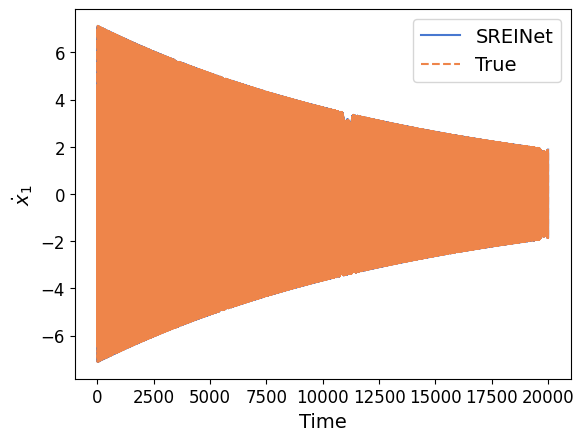

In [17]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [18]:
val_t_span = [0,100]
val_t_eval = np.arange(0,100,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

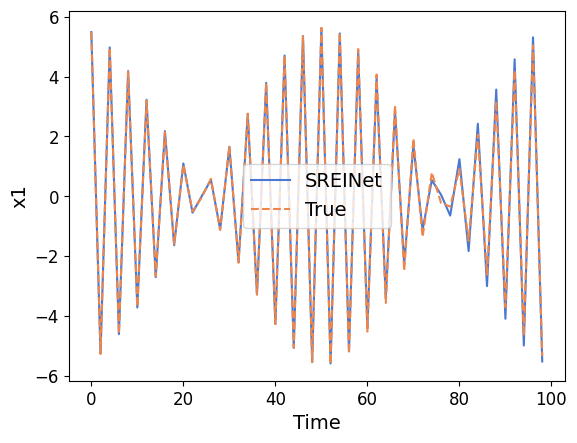

In [19]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()



In [20]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity // dim
print(f"complexity per dimension: {complexity_per_dimension}")


Score: 0.9999999967849524
Complexity: 3
complexity per dimension: 1


## **VI. Output**

In [21]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [22]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='Duffing_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/Duffing_nn_configurations.xlsx
